# Create new customized supervised behaviors for your projects

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lucasmiranda42/deepof/blob/master/docs/source/tutorial_notebooks/deepof_custom_behaviors_tutorial.ipynb)

##### What we'll cover:
    
* Define your own customized behaviors.
* Create behaviors for one or multiple mice
* Create binary behaviors (either occurs or does not occur)
* Create continuous behaviors (return continuous values for each video frame)
* Using ROIs with custom behaviors
* Use the DeepOF plotting and data extraction tools with your new behaviors

In [ ]:
# If using Google colab, uncomment and run this cell and the one below to set up the environment
# Note: because of how colab handles the installation of local packages, this cell will kill your runtime.
# This is not an error! Just continue with the cells below.
# import os
# !git clone -q https://github.com/mlfpm/deepof.git
# !pip install -q -e deepof --progress-bar off
# os.chdir("deepof")
# !curl --output tutorial_files.zip https://datashare.mpcdf.mpg.de/s/TbSrod2fm5jbHfL/download
# !unzip tutorial_files.zip

In [2]:
# import os
# os.chdir("deepof")
# import os, warnings
# warnings.filterwarnings('ignore')

This tutorial assumes that you at least "had a look" at the supervised tutorial. Respectively, you should have seen the variety of supervised behaviors DeepOF offers, from single mouse behaviors like "moving" that measures if the center of the mouse moves more than a certain speed to social behaviors like "nosetonose" that detects nose-nose interactions for pairs of mice.  

Obviously, regardless of how many supervised behaviors we would implement, it would never be enough for everyone. There would always be just that one specific movement pattern or social interaction you would like to measure that is very specific to your own setup. But the good news is: DeepOF offers a very powerful solution for you: It allows you to write your own behaviors with your own code to then use them just like all other supervised behaviors with DeepOF. I.e. plot them, apply ROIs to them, extract related data. All of this just works liek it does with the "native" supervised behaviors of DeepOF. Now let's do some imports and then set up soem examples.

In [3]:
import os
import pickle
import deepof.data
import numpy as np
import deepof.visuals
import matplotlib.pyplot as plt
import seaborn as sns

### Define your own customized behaviors.

As usual, let'S load the tutorial project just to have some data to work with.

In [4]:
# Load a previously saved project
my_deepof_project = deepof.data.load_project("./tutorial_files/tutorial_project")

Now we import soem classes and fucntions from DeepOFs annotation_utils section

In [5]:
# First the DeepOF_behavior class. This is what our customied behavior is going to be an isntance 
from deepof.annotation_utils import DeepOF_behavior

# Then some Enums. We will use these to define what type of behavior we are going to create
from deepof.annotation_utils import Behavior_scope, Behavior_output

# A custom Type and class to keep things nicely structured
from deepof.annotation_utils import animal_ids, BehaviorContext

# One of DeepOFs custom postprocessing functions
from deepof.annotation_utils import postprocess_identity

To define a proper DeepOF_behavior we need four things:

* A name: This will be the name DeepOF uses to identify the behavior. It should be a single string without underscores
* A scope: This will tell DeepOF if your behavior is a single-mouse one or a directional or nondirectional behavior for pairs of mice interacting
* An output_type: This will tell DeepOF if your behavior is a "binary" behavior. i.e. it is either present or absent with nothing in-between or a continuous one.
* A compute function: This is the "core" of your custom DeepOF behavior, the function that is used to calculate your behavior.

Beyond that, you can further customize your DeepOF_behavior by adding a few more inputs:

* A postprocessing function: Per default DeepOF will use a simple median-filter as in most behaviors. You can change this to another DeepOF function or write your own.
* A unit: This will determine the unit of measurement of your behavior. The default is "a.u."
* A hex-code color: This will determine the color DeepOf uses to represent your behavior in different plots. Per default DeepOF will choose a color itself

All of this will probably become much more clear if we see a few examples. So let's define two custom behaviors 

This first one will be a small modification of our nose2nose behavior. Instead of detecting when the distance between the noses of our mice is below a threshold, we want to detect when the noses of the mice are a bit closer, but not yet in nose2nose interaction range. Respectively, let's first write the "core", our function:

In [6]:
# All DeepOF behavior functions take two inputs. The first one is the custom BehaviorContext class we imported. 
# This is in essence a namespace that will make everything we might need available to us within the function. 
# The second one is the current animal the function will handle

def mouse_nose_mid_distance(ctx: BehaviorContext, mice_pair: animal_ids):
     
    # As this is going to be a function for paired mouse behavior, we expect mice_pair to contain two animal ids.
    a, b = mice_pair 

    # Now we also need the tracked bodypart positions. We can get them from the "raw_coords" field (a pandas dataTable) in our BehaviorContext ctx
    pos_dframe=ctx.raw_coords
    
    # We are specifically interested in the Noses. So we get the "nsoe" bodypart for both of our animals.
    # The bp function here simply applies the corret formatting. We could also simply write str(a)+"_Nose" 
    nose_m1=ctx.bp(a, "Nose")
    nose_m2=ctx.bp(b, "Nose")

    # And here we calculate all frames within the table in which the noses of both mice are farther away that our "close_contact_tol" 
    # from the supervised parameters but also closer than 3 times that tolerance. Here we create a binary output array
    middle_contact = (
        (np.linalg.norm(pos_dframe[nose_m1] - pos_dframe[nose_m2], axis=1) > float(ctx.params["close_contact_tol"])) & 
        (np.linalg.norm(pos_dframe[nose_m1] - pos_dframe[nose_m2], axis=1) <= 5*float(ctx.params["close_contact_tol"]))
    )
    return middle_contact

Besides the raw bodypart positions, BehaviorContext also contains a lot more data we can access such as distances, angles, speeds, the arena-parameters, the roi-information, and more. It is even possible to add your own signals and input data to it to then make it available during behavior computation. More regarding that later. Let's first continue to finalize our custom behavior. Now that we have finished our "core", we just need to create the DeepOF_behavior itself. This is rather straightforward:

**IMPORTANT**: the name of the DeepOF_behavior variable should differ from the name of the core function, as otherwise a pickling error will occur during saving the supervised annotations!

In [7]:
mouse_nose_mid_distance_behavior=DeepOF_behavior(
    name="nose2nose-mid", # The name for our behavior.
    scope=Behavior_scope.PAIR_NONDIRECTIONAL, # just like deepofs nose2nose, our behavior is pairwise and nondirectional
    output_type=Behavior_output.BINARY, # We choose the binary output type
    compute=mouse_nose_mid_distance, # This is the computation function we just defined
)


And that's it. Our custom behavior is ready to be used. However, before we do that, let's create another example. This time a one-mouse continuous behavior with some custom data added. Let's measure the distance between the nose and tailbase of each mouse and set everything to 0 if the mouse moves faster than a threshold. Further we will do some experiment based "bias-correction"

In [8]:
def mouse_compression(ctx: BehaviorContext, mouse: animal_ids):    

    # As this is going to be a function for single mouse behavior, we expect mouse to contain only one animal id.
    a=mouse

    # We again use the coordinates data_frame
    pos_dframe=ctx.raw_coords

    # We additionally use the lieklyhoods dataframe which contains the the tracking accuracy for each bodypart as a percentage
    likely_dframe=ctx.likelihoods

    # We extract the bodypart names
    m1_nose=ctx.bp(a,"Nose")
    m1_tailbase=ctx.bp(a,"Tail_base")

    # We calculate the distance 
    mouse_compression = np.linalg.norm(pos_dframe[m1_nose]-pos_dframe[m1_tailbase],axis=1)

    # We set all our "compression" values to 0 at frames where the nose or tail base of the mouse is not accurately detected 
    # i.e. the likelyhood value is below the threshold we defined
    mouse_compression = mouse_compression*(likely_dframe[m1_nose]>ctx.extra['likelyhood_threshold'])
    mouse_compression = mouse_compression*(likely_dframe[m1_tailbase]>ctx.extra['likelyhood_threshold'])

    # Whilst likelyhood_threshold will be the same value for all of our experiments, we can also add custom dictionaries to our extra parameters 
    # and call specific entries in them e.g. with ctx.key, which would be the key to our current experiment. 
    mouse_compression = mouse_compression*ctx.extra['bias_correction_dict'][ctx.key]

    return mouse_compression

Now we again have to define the corresponding DeepOF_behavior

In [9]:
mouse_compression_behavior=DeepOF_behavior(
    name="is-compressed",
    scope=Behavior_scope.INDIVIDUAL,
    output_type=Behavior_output.CONTINUOUS,
    compute=mouse_compression,
    postprocess=postprocess_identity, # here we use the identity-postprocessing function from deepof i.e. no postprocessing is applied at all.
)

Lastly, let's add our custom parameter values 'bias_correction_dict' and 'likelyhood_threshold' to our BehaviorContext. We do this by packaging them into a dictionary. 

In [10]:
# We first generate our custom bias_correction_dict that contains, for this example, just different random values for each of our experiments
np.random.seed=0
bias_correction_dict={key: np.random.uniform()+1 for key in my_deepof_project._tables.keys()}

# packaging our parameters
custom_behavior_context={

    'bias_correction_dict' : bias_correction_dict,
    'likelyhood_threshold' : 0.5,
}

Now we can run the supervised annotations with our new custom behaviors and add our custom_behavior_context 

In [11]:
supervised_annotation = my_deepof_project.supervised_annotation(custom_behaviors=[mouse_nose_mid_distance_behavior, mouse_compression_behavior], custom_behavior_context=custom_behavior_context)

supervised annotations        : 100%|██████████| 53/53 [01:22<00:00,  1.56s/table, step=post processing]   


Let's have our look at our new custom behaviors. Since "is-compressed" is a continuous behavior, it will not be shown in the Gantt plot. But we can use it as a signal overlay for the Gantt plot, just as we used the speed signal in the [supervised tutorial](https://deepof.readthedocs.io/en/latest/tutorial_notebooks/deepof_supervised_tutorial.html).

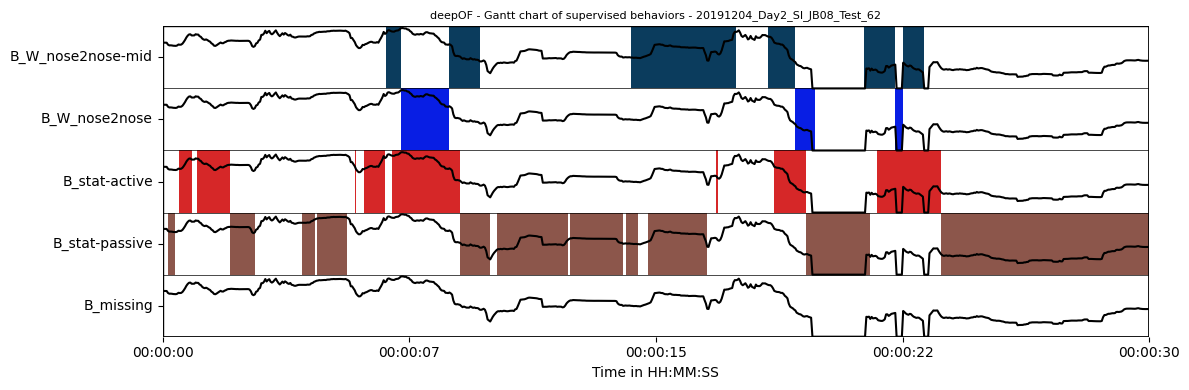

In [12]:
# Let's retrieve the speed of the black mouse from our supervised behaviors
speed_black_mouse=supervised_annotation["20191204_Day2_SI_JB08_Test_62"]["B_is-compressed"]

plt.figure(figsize=(12, 4))

deepof.visuals.plot_gantt(
    my_deepof_project,
    "20191204_Day2_SI_JB08_Test_62",
    supervised_annotations=supervised_annotation,
    bin_index="00:00:00",
    bin_size="00:00:30",
    signal_overlay=speed_black_mouse,
    instances_to_plot=['B_W_nose2nose','B_W_nose2nose-mid','B_stat-passive', 'B_stat-active', 'B_missing'],
)

plt.show()

In this plot we can see now how, as expected, the nose2nose interactions are usually surrounded by nose2nose-mid interactions. An exception is the second nose2nose interaction as the mid-range interaction after it is missing. Looking at our signal-overlay, we can see how it is also set to 0 at that position, meaning that the tracking accuracy of the nose (or tail base) of the black mouse is below our threshold in that region. Furthermore, our "compression"-signal is lower in genral in the last third of this Gantt-plot section and also dipping to 0 a few times.

Based on this we can conclude that the black mouse is likely in a hunched or crouched position in that section of the video, which makes tracking-errors or -failuers of individual bodyparts more likely. Whilst the mouse is not missing in it's entirety, it is stationary and it's bodyparts are so close together, that some of them are not detected all the time.

A brief check at the corresponding video between seconds 15-25 reveals this to be the case

![custom_behaviors](./Assets/custom_behaviors.gif)

In [13]:
# You can recreate this video via:

'''
deepof.visuals.export_annotated_video(
    my_deepof_project,
    supervised_annotations = supervised_annotation,
    # Time selection parameters
    bin_size = "0:0:10",
    bin_index = "0:0:15",
    precomputed_bins = None,
    frame_limit_per_video = 1000,
    # behaviors and experiment
    behaviors = ['B_W_nose2nose','B_W_nose2nose-mid','B_stat-passive', 'B_stat-active', 'B_missing'],
    experiment_id = "20191204_Day2_SI_JB08_Test_62",
    min_confidence = 0.0,
    min_bout_duration = None,
    display_time = True,
    display_counter = True,
    display_arena = True,
    display_markers = True,
    cluster_names = None,
)
'''

'\ndeepof.visuals.export_annotated_video(\n    my_deepof_project,\n    supervised_annotations = supervised_annotation,\n    # Time selection parameters\n    bin_size = "0:0:10",\n    bin_index = "0:0:15",\n    precomputed_bins = None,\n    frame_limit_per_video = 1000,\n    # behaviors and experiment\n    behaviors = [\'B_W_nose2nose\',\'B_W_nose2nose-mid\',\'B_stat-passive\', \'B_stat-active\', \'B_missing\'],\n    experiment_id = "20191204_Day2_SI_JB08_Test_62",\n    min_confidence = 0.0,\n    min_bout_duration = None,\n    display_time = True,\n    display_counter = True,\n    display_arena = True,\n    display_markers = True,\n    cluster_names = None,\n)\n'

### Using ROIs with custom behaviors

The ROIs are among other things you have access to, when defining a custom behavior. Respectively, you can e.g. detect if a mouse is entering a specific ROI. For this let us borrow two polygon functions from DeepOFs utils: point_in_polygon_numba and get_point_polygon_distance_numba

In [14]:
from deepof.utils import point_in_polygon_numba, get_point_polygon_distance_numba             

Then we define our behavior core function as follows. To make this into an actually usable example, we have to consider some edge cases and do some smoothing and polishing:

In [15]:
import pandas as pd

def mouse_enters_roi_1(ctx: BehaviorContext, mouse: animal_ids):

    # we get the usual context information, this time also the speeds dataframe
    a = mouse    
    pos_dframe = ctx.raw_coords
    speed_dframe = ctx.speeds
    likely_dframe=ctx.likelihoods
    m1_nose = ctx.bp(a, "Nose")
    m1_center = ctx.bp(a, "Center")

    # We use the coordinates data_frame and roi 1 from each experiment
    roi_polygon = ctx.roi_dict[1]

    # We convert our nose coordinates to a numpy array
    pts = pos_dframe[m1_nose].to_numpy().astype(np.float64)

    # We detect all frames in which the nose of the mouse has been inside of the polygon
    inside = deepof.utils.point_in_polygon_numba(pts, roi_polygon)

    # We get the speed of the center and tracking accuracy of the nose
    speed = speed_dframe[m1_center].to_numpy() 
    nose_likelihood = likely_dframe[m1_nose].to_numpy()

    # In case of gaps in the tracking, we fill inside with the neighboring frames
    tracking_gap = np.isnan(pts[:,0])
    inside = (
        pd.Series(inside)
        .mask(tracking_gap) # set frames at tracking gap frames to NaN
        .ffill()            # fill from previous confident frame
        .bfill()            # fill any initial NaNs from the next confident frame
        .fillna(False)      # in case *all* frames are low-confidence
        .to_numpy(dtype=bool)
    )

    # We detect entering events i.e. inside now AND outside previous frame and exiting events as the reverse
    prev_inside = np.concatenate(([True], inside[:-1]))
    entering = inside & (~prev_inside)
    exiting = ~inside & (prev_inside)

    # We ignore entries where the mouse is stationary or where the nose tracking accuracy is poor
    entering &= (speed > float(ctx.params["stationary_threshold"]))
    entering &= (nose_likelihood > float(ctx.params["nose_likelihood"]))
    exiting &= (speed > float(ctx.params["stationary_threshold"]))
    exiting &= (nose_likelihood > float(ctx.params["nose_likelihood"]))

    # We ignore entries with multiple entering or exiting events in close proximity. For this we first count events within a 1 second window
    win = int(np.round(ctx.frame_rate))
    events = (entering | exiting).astype(np.uint8)
    event_count = np.convolve(events, np.ones(win, dtype=np.uint8), mode="same")

    # Then we keep only isolated events
    entering &= (event_count == 1)

    # We widen the entering events, to make them a bit more noticable
    entering = (np.convolve(entering.astype(np.uint8), np.ones(win, dtype=np.uint8), mode="same") > 0)   

    return entering

We define the behavior as a single-mouse binary behavior and run the supervised_annotations with it

In [16]:
enters_roi_1=DeepOF_behavior(
    name="enters-roi-1",
    scope=Behavior_scope.INDIVIDUAL,
    output_type=Behavior_output.BINARY,
    compute=mouse_enters_roi_1,
)

In [17]:
supervised_annotation = my_deepof_project.supervised_annotation(custom_behaviors=[enters_roi_1])

data preprocessing            :   0%|          | 0/4 [00:00<?, ?step/s, step=Loading raw coords]

supervised annotations        : 100%|██████████| 53/53 [01:21<00:00,  1.54s/table, step=post processing]   


This then results in the following detections:

![custom_behaviors_roi](./Assets/custom_behaviors_roi.gif)

In [18]:
# You can recreate this video via:

'''
deepof.visuals.export_annotated_video(
    my_deepof_project,
    supervised_annotations = supervised_annotation,
    # Time selection parameters
    precomputed_bins = None,
    frame_limit_per_video = 100,
    # behaviors and experiment
    behaviors = ['B_enters-roi-1'],
    min_confidence = 0.0,
    min_bout_duration = None,
    display_time = True,
    display_counter = True,
    display_arena = True,
    display_markers = True,
    cluster_names = None,
    display_roi=1,
)
'''

"\ndeepof.visuals.export_annotated_video(\n    my_deepof_project,\n    supervised_annotations = supervised_annotation,\n    # Time selection parameters\n    precomputed_bins = None,\n    frame_limit_per_video = 100,\n    # behaviors and experiment\n    behaviors = ['B_enters-roi-1'],\n    min_confidence = 0.0,\n    min_bout_duration = None,\n    display_time = True,\n    display_counter = True,\n    display_arena = True,\n    display_markers = True,\n    cluster_names = None,\n    display_roi=1,\n)\n"

As you can see, writing useful supervised behaviors is not trivial, but very powerful. You can even train your own classifiers and call them within your custom behavior core function to then use DeepOF with them. However, this is something that is currently out of the scope of this tutorial.

### What's next

With this you now should have a good insight into the supervised capabilities of DeepOF. Next, we can explore "the other branch" of the package: we'll learn to embed our data in a sequence-aware manner, to get behavioral patterns in an *unsupervised* way using deep clustering (where the "deep" in DeepOF comes from). In short [the unsupervised branch](https://deepof.readthedocs.io/en/latest/tutorial_notebooks/deepof_unsupervised_tutorial.html) for detecting behavior patterns only from tracking data in an unbiased way. See you there!